In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.core.pylabtools import figsize
from nltk import download, accuracy
from torch import optim
from torch.xpu import device
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn as nn
from torch import optim
import torchvision.transforms.functional as F
from torchvision import datasets, transforms

In [2]:
DEVICE = torch.device("mps" if torch.mps.is_available() else 'cpu')

In [3]:
train_dataset = datasets.EMNIST(
    root ='./data',
    split='letters',
    train= True,
    download=True,
)

In [4]:
test_dataset = datasets.EMNIST(
    root ='./data',
    split = 'letters',
    train= False,
    download= True
)

In [5]:
mean = (0.1736,)
std = (0.3317,)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean= mean, std = std)
])

In [6]:
train_dataset.transform = transform
test_dataset.transform = transform

In [7]:
img_tensor, label = train_dataset[40000]

### Shape of the img_tensor

In [8]:
print(img_tensor.shape)

torch.Size([1, 28, 28])


In [9]:
def correct_image_orientation(image):
    rotated = F.rotate(image,90)
    flipped = F.vflip(rotated)
    return flipped

In [10]:
img_transformed = correct_image_orientation(img_tensor)

In [11]:
def convert_emnist_label_to_char(label):
    if not ( 1 <= label <= 26):
        raise ValueError("Label must be between 1 and 26 inclusive")

    upper_char = chr(64 + label)

    lower_char = chr(96 + label)

    char_tuple = (upper_char, lower_char)

    return char_tuple

In [12]:
def visualize_image(img, label=None, ax=None):
    if isinstance(img, torch.Tensor):
        img = img.numpy().squeeze()
    elif isinstance(img, np.ndarray):
        if img.ndim == 3:
            img = img[:,:,0]

    if label is not None:
        upper_case_char, lower_case_char = convert_emnist_label_to_char(label)
        title = f"EMNIST Letter: {upper_case_char}/{lower_case_char}"
    else:
        title = None

    if ax is None:
        fig,ax = plt.subplots(figsize=(5,5))
        show_colorbar = True

    else:
        show_colorbar = False

    im = ax.imshow(img, cmap='gray')

    ax.set_xticks(np.arange(0,28,1))
    ax.set_yticks(np.arange(0, 28, 1))
    ax.tick_params(labelsize=6)
    ax.grid(True, color="red", alpha=0.3)

    if title:
        ax.set_title(title)

    if show_colorbar:
        plt.colorbar(im, ax=ax)

    plt.show()


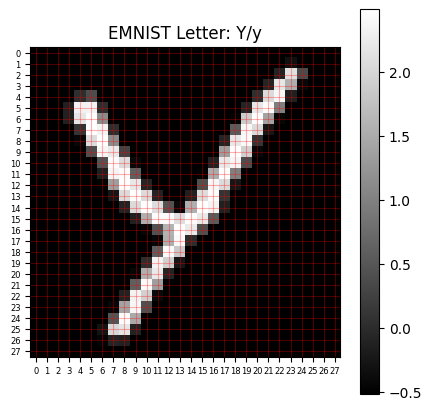

In [13]:
visualize_image(img_transformed, label)

### Loading Data

In [14]:
def create_emnist_dataloaders(train_dataloader, test_dataloader, batch_size=64):

    train_dataloader = DataLoader(
        train_dataloader,
        batch_size = batch_size,
        shuffle= True
    )

    test_dataloader = DataLoader(
        test_dataloader,
        batch_size = batch_size,
        shuffle = False
    )

    return train_dataloader, test_dataloader


In [15]:
train_loader, test_loader = create_emnist_dataloaders(train_dataset,test_dataset, batch_size=64)

In [16]:
def display_data_loader_contents(data_loader):

    try:
        print("Total number of images in dataset:", len(data_loader.dataset))
        print("Total number of batches:", len(data_loader))

        for batch_idx, (data, labels) in enumerate(data_loader):
            print(f"--- Batch {batch_idx + 1} ---")
            print(f"Data shape: {data.shape}")
            print(f"Label shape: {labels.shape}")
            break

    except StopIteration:
        print("data loader is empty")
    except Exception as err:
        print(f"And error occurred: {err}")

In [17]:
print("--- Train Loader ---\n")
display_data_loader_contents(train_loader)
print("--- Test Loader ---\n")
display_data_loader_contents(test_loader)

--- Train Loader ---

Total number of images in dataset: 124800
Total number of batches: 1950
--- Batch 1 ---
Data shape: torch.Size([64, 1, 28, 28])
Label shape: torch.Size([64])
--- Test Loader ---

Total number of images in dataset: 20800
Total number of batches: 325
--- Batch 1 ---
Data shape: torch.Size([64, 1, 28, 28])
Label shape: torch.Size([64])


### Neural Network

In [18]:
def initialize_emnist_model(num_classes=26):
    torch.manual_seed(42)

    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784,256),
        nn.ReLU(),
        nn.Linear(256,128),
        nn.ReLU(),
        nn.Linear(128, num_classes)
    )

    loss_function = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters())

    return model, loss_function, optimizer

In [19]:
model, loss_function, optimizer = initialize_emnist_model(num_classes=26)

In [20]:
print(f"model's architecture:\n\n{model}\n")
print(f"model's loss function: {loss_function}\n")
print(f"model's optimizer:\n\n{optimizer}\n")

model's architecture:

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=26, bias=True)
)

model's loss function: CrossEntropyLoss()

model's optimizer:

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)



In [30]:
def train_epoch(model, loss_function, optimizer, train_loader, device, verbose=True):
    model.to(device)
    model.train()

    running_loss = 0.0
    num_correct_predictions = 0
    total_predictions = 0

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device),  targets.to(device)

        targets = targets - 1

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_function(outputs, targets)

        loss.backward()

        optimizer.step()

        loss_value = loss.item()
        running_loss  += loss_value

        predicted_indices = outputs.argmax(dim=1)
        correct_predictions = (predicted_indices == targets)
        num_correct_in_batch = correct_predictions.sum().item()
        num_correct_predictions += num_correct_in_batch

        batch_size = targets.size(0)
        total_predictions += batch_size

    average_loss = running_loss / len(train_loader)
    accuracy_percentage = (num_correct_predictions / total_predictions) * 100

    if verbose:
        print(f"Epoch Loss (Avg): {average_loss:.3f}| Epoch Acc: {accuracy_percentage:.2f}%")


    return model, average_loss


### Sanity Check

In [36]:
model, loss_function, optimizer = initialize_emnist_model(num_classes=26)

In [37]:

model_one_train_epoch, _ = train_epoch(model=model, # model
                                       loss_function=loss_function, # loss_function
                                       optimizer=optimizer, # optimizer
                                       train_loader=train_loader, # train_loader
                                       device=DEVICE) # DEVICE

Epoch Loss (Avg): 0.600| Epoch Acc: 81.53%


### Model Evaluation

In [ ]:
def evaluagte(mo)